### 1.1 Импортируем библиотеки

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
from scipy.stats import randint
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
data = pd.read_parquet('../data/dataset.parquet')

In [75]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, results_df=None):
    """
    Оценивает модель и возвращает DataFrame с метриками
    
    Parameters:
    - model: обученная модель
    - X_train, X_test: признаки
    - y_train, y_test: целевые переменные
    - model_name: название модели
    - results_df: существующий DataFrame для добавления результатов
    
    Returns:
    - results_df: DataFrame с метриками
    """
    
    # Предсказания
    # y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Вычисление метрик для train и test
    metrics = {
        'Model': model_name,
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'Test_F1': f1_score(y_test, y_test_pred),
        'Test_ROC_AUC': roc_auc_score(y_test, y_test_proba),
        'Test_AP': average_precision_score(y_test, y_test_proba),
    }
    
    # Создание или обновление DataFrame
    if results_df is None:
        results_df = pd.DataFrame([metrics])
    else:
        new_row = pd.DataFrame([metrics])
        results_df = pd.concat([results_df, new_row], ignore_index=True)
    
    return results_df

In [91]:
#Матрица ошибок
def confusion_matrix_graf(model, X_train, X_test, y_train, y_test, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    from sklearn.metrics import confusion_matrix as cm
    
    cm_train = cm(y_train, model.predict(X_train))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title(f'Confusion Matrix - Train {model_name}')  # исправлено name_model на model_name
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    
    cm_test = cm(y_test, model.predict(X_test))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title(f'Confusion Matrix - Test {model_name}')  # исправлено name_model на model_name
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

In [94]:
def roc_curves_graf(X_train, X_test, y_train, y_test, model, model_name):
    plt.figure(figsize=(10, 8))
    
    # ROC для train
    fpr_train, tpr_train, _ = roc_curve(y_train, model.predict_proba(X_train)[:, 1])
    roc_auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    
    # ROC для test
    fpr_test, tpr_test, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    roc_auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    plt.plot(fpr_train, tpr_train, color='blue', lw=2, 
             label=f'Train ROC (AUC = {roc_auc_train:.4f})')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
             label=f'Test ROC (AUC = {roc_auc_test:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label=f'{model_name}')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Train vs Test')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [96]:
def precision_recall_curves_graf(X_test, X_train, y_train, y_test, model, model_name):
    plt.figure(figsize=(10, 8))
    
    # Precision-Recall для train
    precision_train, recall_train, _ = precision_recall_curve(y_train, model.predict_proba(X_train)[:, 1])
    ap_train = average_precision_score(y_train, model.predict_proba(X_train)[:, 1])
    
    # Precision-Recall для test
    precision_test, recall_test, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])
    ap_test = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
    
    plt.plot(recall_train, precision_train, color='blue', lw=2, 
             label=f'Train PR (AP = {ap_train:.4f})')
    plt.plot(recall_test, precision_test, color='red', lw=2, 
             label=f'Test PR (AP = {ap_test:.4f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curves - Train vs Test {model_name}')
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442961 entries, 0 to 442960
Data columns (total 78 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   borrow_block_number                      442961 non-null  int64  
 1   borrow_timestamp                         442961 non-null  float64
 2   wallet_address                           442961 non-null  object 
 3   first_tx_timestamp                       442961 non-null  float64
 4   last_tx_timestamp                        442961 non-null  float64
 5   wallet_age                               442961 non-null  float64
 6   incoming_tx_count                        442961 non-null  int64  
 7   outgoing_tx_count                        442961 non-null  int64  
 8   net_incoming_tx_count                    442961 non-null  int64  
 9   total_gas_paid_eth                       442961 non-null  float64
 10  avg_gas_paid_per_tx_eth         

In [7]:
data.shape

(442961, 78)

In [8]:
data.columns

Index(['borrow_block_number', 'borrow_timestamp', 'wallet_address',
       'first_tx_timestamp', 'last_tx_timestamp', 'wallet_age',
       'incoming_tx_count', 'outgoing_tx_count', 'net_incoming_tx_count',
       'total_gas_paid_eth', 'avg_gas_paid_per_tx_eth', 'risky_tx_count',
       'risky_unique_contract_count', 'risky_first_tx_timestamp',
       'risky_last_tx_timestamp', 'risky_first_last_tx_timestamp_diff',
       'risky_sum_outgoing_amount_eth', 'outgoing_tx_sum_eth',
       'incoming_tx_sum_eth', 'outgoing_tx_avg_eth', 'incoming_tx_avg_eth',
       'max_eth_ever', 'min_eth_ever', 'total_balance_eth', 'risk_factor',
       'total_collateral_eth', 'total_collateral_avg_eth',
       'total_available_borrows_eth', 'total_available_borrows_avg_eth',
       'avg_weighted_risk_factor', 'risk_factor_above_threshold_daily_count',
       'avg_risk_factor', 'max_risk_factor', 'borrow_amount_sum_eth',
       'borrow_amount_avg_eth', 'borrow_count', 'repay_amount_sum_eth',
       'repay_am

In [9]:
data = data.drop('wallet_address', axis=1)

In [10]:
data.describe(include='float64')

,borrow_timestamp,first_tx_timestamp,last_tx_timestamp,wallet_age,total_gas_paid_eth,avg_gas_paid_per_tx_eth,risky_sum_outgoing_amount_eth,outgoing_tx_sum_eth,incoming_tx_sum_eth,outgoing_tx_avg_eth,...,market_macdsignal_macdext,market_macdsignal_macdfix,market_macdsignal,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr
count,4.429610e+05,4.429610e+05,4.429610e+05,4.429610e+05,442961.000000,442961.000000,4.429610e+05,4.429610e+05,4.429610e+05,442961.000000,...,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000
mean,1.629225e+09,1.593978e+09,1.629120e+09,3.524693e+07,26.898496,0.015685,2.312860e+04,1.071285e+05,1.030546e+05,31.891906,...,25.942980,22.369506,23.478711,-0.650871,6.102657,23.324148,1062.136487,2.020113,0.038512,1.038512
std,2.972367e+07,4.485955e+07,2.970179e+07,3.828899e+07,141.471489,0.030737,2.230375e+05,7.097087e+05,6.549361e+05,250.161534,...,157.747496,102.262312,107.338012,0.127519,2.281503,9.257275,21143.683448,8.304551,0.176627,0.176627
min,1.557197e+09,1.438270e+09,1.557197e+09,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,-533.215038,-274.787793,-288.690622,-0.992921,2.842363,4.674813,5.413265,-29.248726,-0.545814,0.454186
25%,1.610250e+09,1.570976e+09,1.610199e+09,6.621387e+06,0.364798,0.005112,0.000000e+00,6.151085e+01,7.979699e+01,0.277378,...,-41.164218,-25.716493,-26.736740,-0.736622,4.393287,15.907632,129.436901,-3.275724,-0.068142,0.931858
50%,1.624652e+09,1.601186e+09,1.624549e+09,2.120514e+07,2.268351,0.010691,4.382761e+01,7.793659e+02,8.290144e+02,1.531728,...,11.972290,8.946516,9.423609,-0.668490,5.569394,22.166548,333.246607,1.652219,0.023303,1.023303
75%,1.653123e+09,1.621893e+09,1.653021e+09,5.088168e+07,12.675138,0.018049,8.957546e+02,8.697555e+03,8.865910e+03,7.925058,...,104.865957,83.314472,87.762008,-0.608560,7.284896,29.496384,560.550257,7.337788,0.138449,1.138449
max,1.696118e+09,1.696060e+09,1.701649e+09,2.547487e+08,9951.709230,2.586824,1.294037e+07,2.021488e+07,2.014653e+07,30211.095748,...,570.929181,372.715172,391.719370,-0.361351,15.106064,56.729534,807296.000000,28.435216,0.768294,1.768294


In [11]:
data.describe(include='int64')

,borrow_block_number,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,risky_tx_count,risky_unique_contract_count,risky_first_tx_timestamp,risky_last_tx_timestamp,risky_first_last_tx_timestamp_diff,borrow_count,repay_count,deposit_count,liquidation_count,market_ht_trendmode,unique_borrow_protocol_count,unique_lending_protocol_count,target
count,4.429610e+05,442961.000000,4.429610e+05,442961.000000,442961.000000,442961.000000,4.429610e+05,4.429610e+05,4.429610e+05,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000,442961.000000
mean,1.304907e+07,777.858238,2.196224e+03,-1418.365727,118.291513,18.720851,1.483994e+09,1.497026e+09,1.303211e+07,60.942146,46.051842,72.793492,1.420249,0.925154,0.975084,1.223742,0.375202
std,2.231888e+06,2306.781076,2.803049e+04,27699.991076,314.279904,35.596185,2.515203e+08,2.584733e+08,1.759031e+07,202.519253,175.857355,318.035593,10.950239,0.263144,0.558809,0.443834,0.484176
min,7.711117e+06,0.000000,0.000000e+00,-996456.000000,0.000000,0.000000,1.000000e+09,1.000000e+09,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.162464e+07,39.000000,5.800000e+01,-273.000000,1.000000,1.000000,1.592219e+09,1.594498e+09,0.000000e+00,2.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,1.270531e+07,158.000000,2.480000e+02,-62.000000,17.000000,6.000000,1.600174e+09,1.618701e+09,5.400272e+06,9.000000,3.000000,11.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,1.481634e+07,567.000000,9.210000e+02,-9.000000,88.000000,20.000000,1.619090e+09,1.638324e+09,1.997586e+07,37.000000,20.000000,41.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.825192e+07,197999.000000,1.003714e+06,196374.000000,10364.000000,843.000000,1.696097e+09,1.696104e+09,1.040981e+08,7500.000000,6255.000000,8603.000000,204.000000,1.000000,4.000000,2.000000,1.000000


In [12]:
time_columns = [
    'borrow_timestamp', 'first_tx_timestamp', 'last_tx_timestamp',
    'risky_first_tx_timestamp', 'risky_last_tx_timestamp'
]

In [13]:
df = data.copy()
for i in time_columns:
    if i in data.columns:
        df[i] = pd.to_datetime(data[i],unit='s')

In [14]:
df.describe(include='datetime64')

,borrow_timestamp,first_tx_timestamp,last_tx_timestamp,risky_first_tx_timestamp,risky_last_tx_timestamp
count,442961,442961,442961,442961,442961
mean,2021-08-17 18:22:11.321940224,2020-07-05 19:33:22.714699776,2021-08-16 13:14:20.570399488,2017-01-09 20:35:35.081645312,2017-06-09 16:37:26.175311104
min,2019-05-07 02:48:28,2015-07-30 15:26:13,2019-05-07 02:44:34,2001-09-09 01:46:39,2001-09-09 01:46:39
25%,2021-01-10 03:33:34,2019-10-13 14:12:58,2021-01-09 13:24:00,2020-06-15 11:08:26,2020-07-11 20:04:48
50%,2021-06-25 20:19:41,2020-09-27 06:00:15,2021-06-24 15:44:48,2020-09-15 12:43:10,2021-04-17 23:01:56
75%,2022-05-21 08:55:35,2021-05-24 21:43:44,2022-05-20 04:26:50,2021-04-22 11:13:19,2021-12-01 02:06:50
max,2023-09-30 23:51:23,2023-09-30 07:53:35,2023-12-04 00:22:59,2023-09-30 17:58:59,2023-09-30 20:07:59


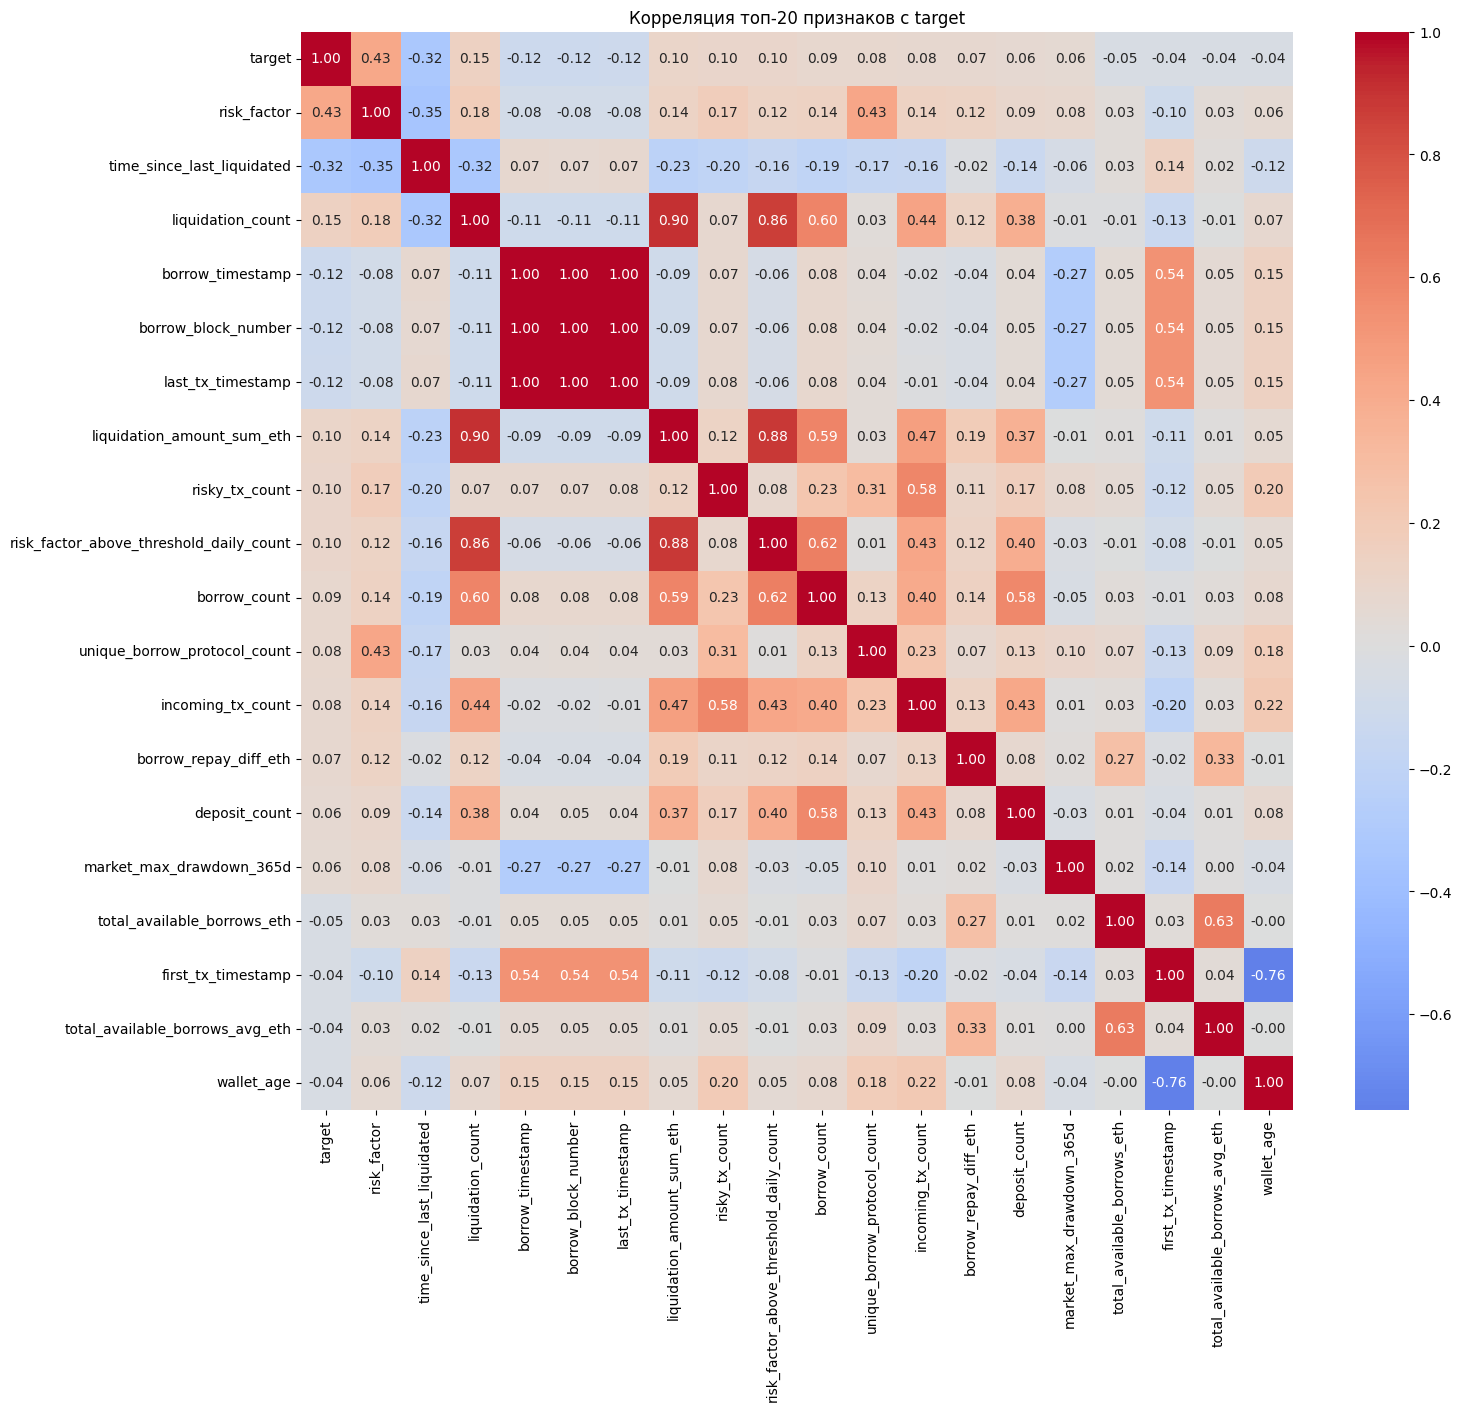

In [27]:
if 'target' in data.select_dtypes(include=['number']).columns:
    corr_with_target = data.select_dtypes(include=['number']).corr()['target'].abs().sort_values(ascending=False)
    top_columns = corr_with_target.head(20).index
    top_data = data.select_dtypes(include=['number'])[top_columns]
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(top_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Корреляция топ-20 признаков с target')
    plt.show()

In [15]:
X = data.drop('target',axis=1)
y = data.target

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [17]:
numeric_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [82]:
rfc = RandomForestClassifier(n_estimators=100, random_state=21, n_jobs=-1)

In [83]:
rfc.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=21)

In [113]:
results_df = pd.DataFrame()

In [114]:
results_df = evaluate_model(
    model=rfc,  # ваша обученная модель
    X_train=X_train_scaled,
    X_test=X_test_scaled, 
    y_train=y_train,
    y_test=y_test,
    model_name='Random Forest',
    results_df=results_df
)

In [108]:
results_df

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_AP
0,Random Forest,0.897859,0.930552,0.786462,0.852461,0.958292,0.943403


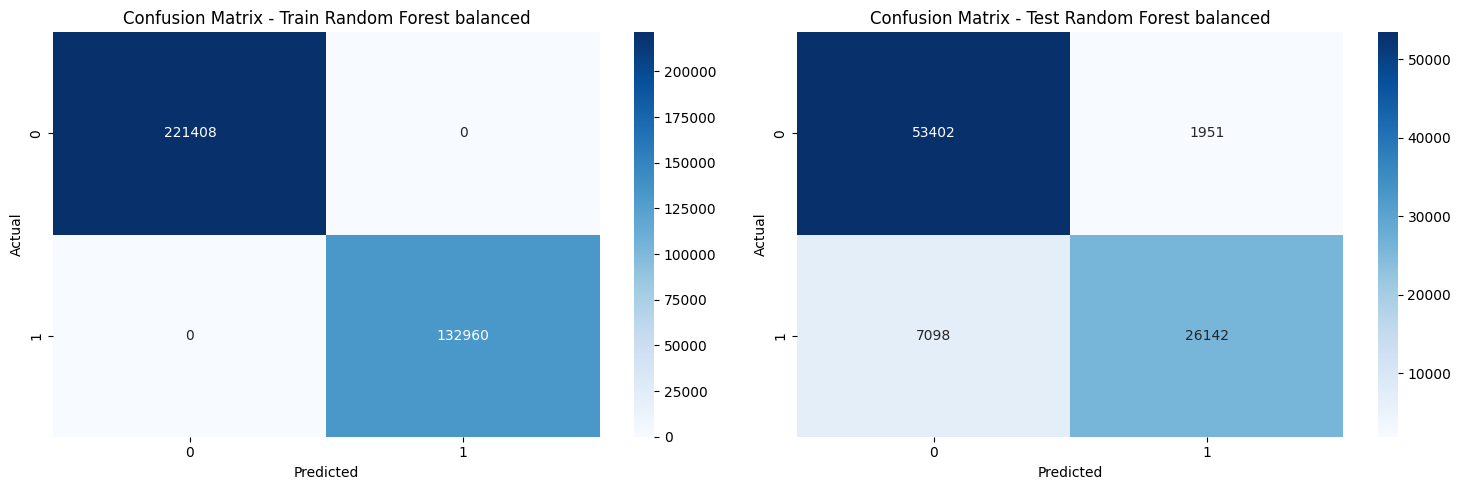

In [92]:
confusion_matrix_graf(    
    # ваша обученная модель
    model=rfc,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='Random Forest'
)

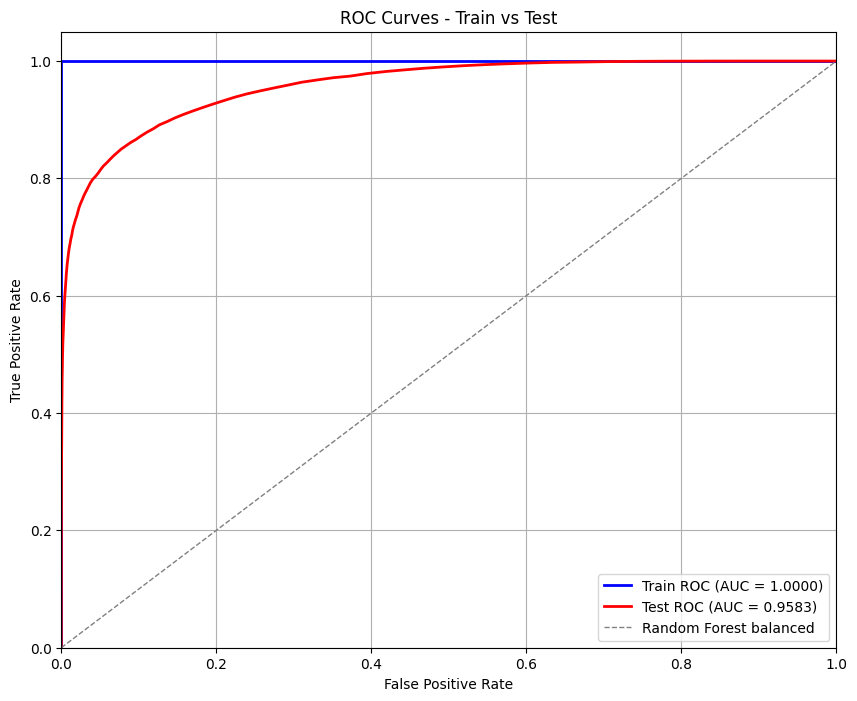

In [95]:
roc_curves_graf(
    model=rfc,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='Random Forest'
)

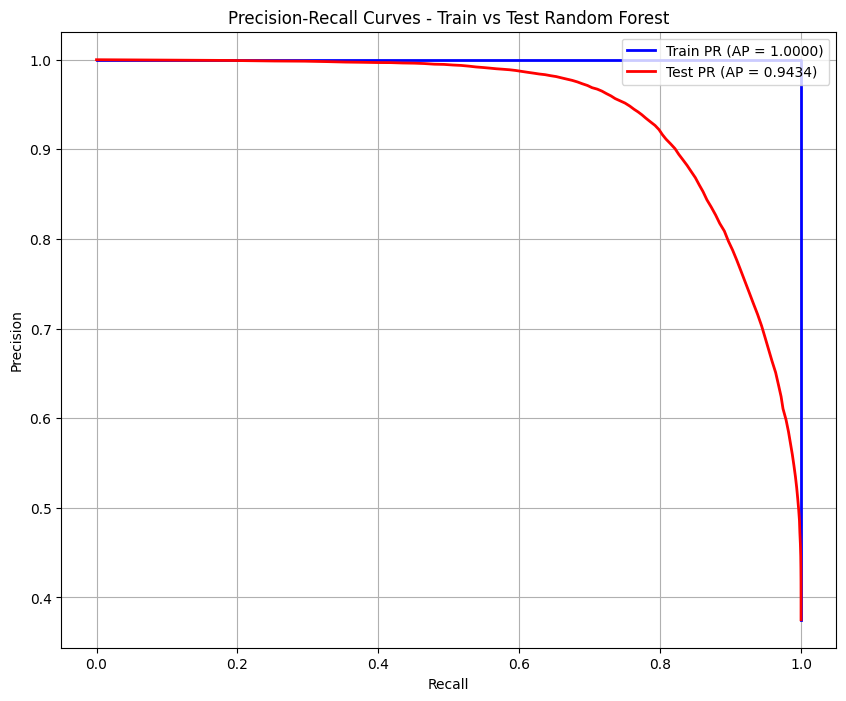

In [98]:
precision_recall_curves_graf(
    model=rfc,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='Random Forest'
)

In [100]:
lr = LogisticRegression(random_state=21, max_iter=1000, solver='liblinear', n_jobs=12)

In [101]:
lr.fit(X_train_scaled, y_train)

/home/GUSZN.LOCAL/nadelyaev-sp/miniconda/envs/example/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


LogisticRegression(max_iter=1000, n_jobs=-1, random_state=21,
                   solver='liblinear')

In [115]:
results_df = evaluate_model(
    model=lr,  # ваша обученная модель
    X_train=X_train_scaled,
    X_test=X_test_scaled, 
    y_train=y_train,
    y_test=y_test,
    model_name='Logistic Regression',
    results_df=results_df
)

In [116]:
results_df

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_AP
0,Random Forest,0.897859,0.930552,0.786462,0.852461,0.958292,0.943403
1,Logistic Regression,0.772781,0.761949,0.573616,0.654504,0.793777,0.757827


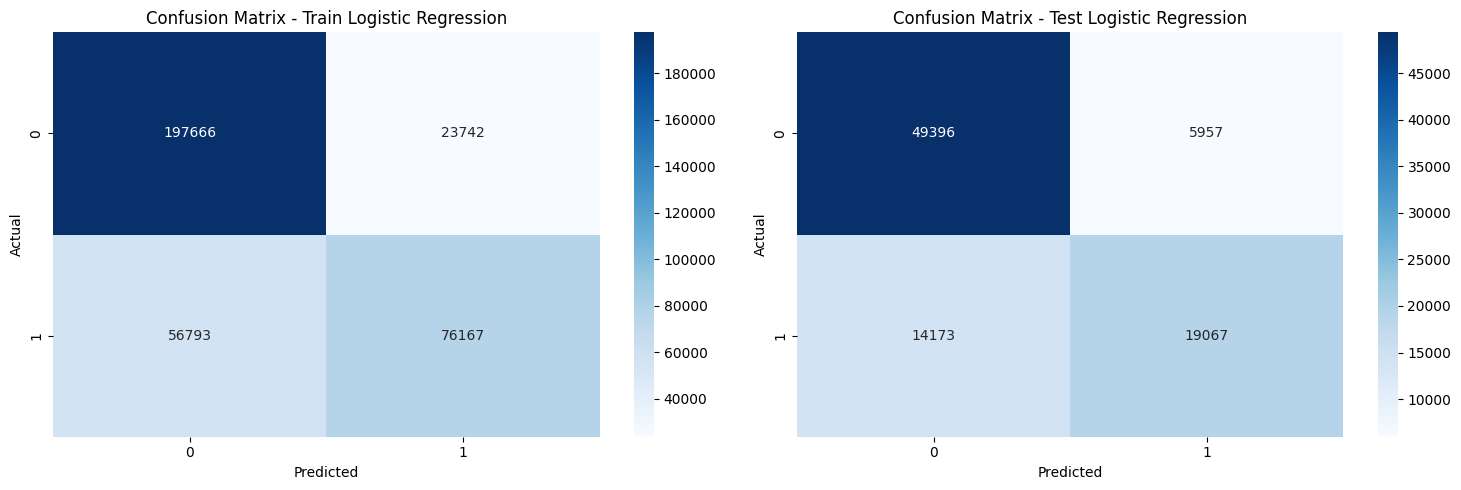

In [117]:
confusion_matrix_graf(    
    # ваша обученная модель
    model=lr,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='Logistic Regression'
)

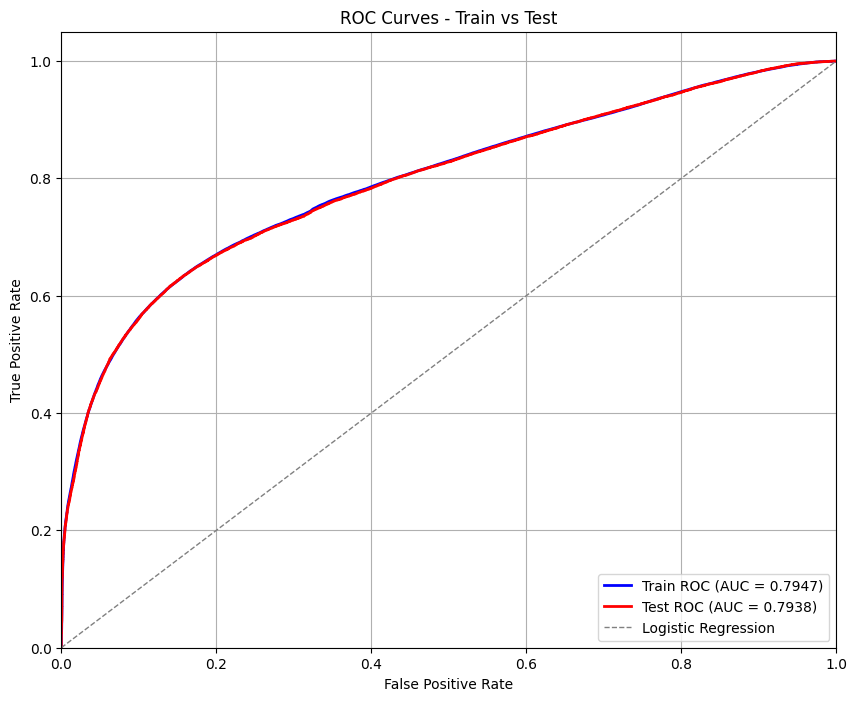

In [118]:
roc_curves_graf(
    model=lr,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='Logistic Regression'
)

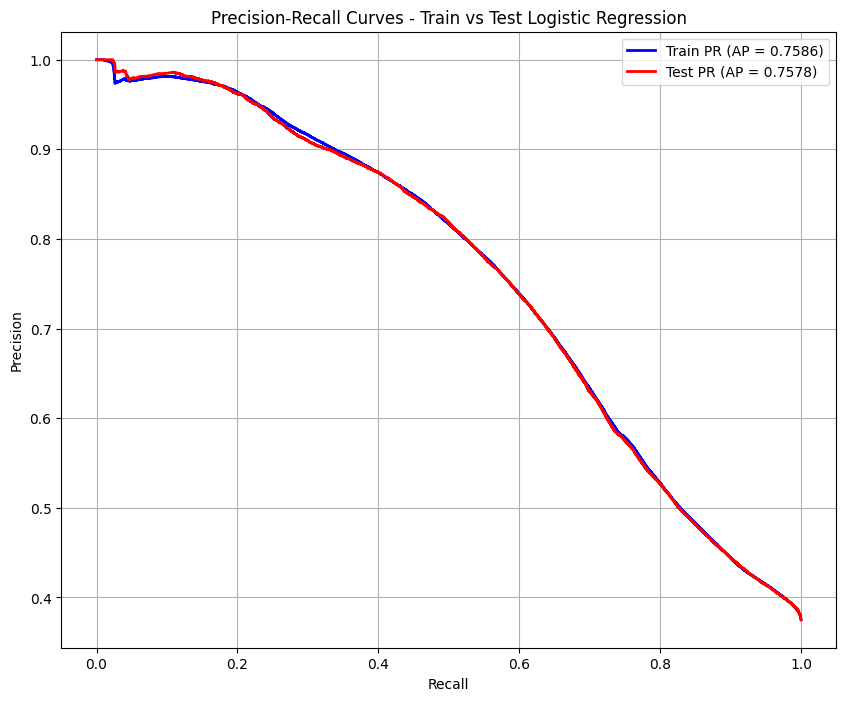

In [119]:
precision_recall_curves_graf(
    model=lr,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='Logistic Regression'
)

In [120]:
xgb = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=1000,
    subsample=0.9,
    eval_metric='logloss',
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=21,
    n_jobs=12
)

In [128]:
param_distributions = {
    'max_depth': [4, 5, 6],           # было 5 значений
    'learning_rate': [0.05, 0.1],     # было 4 значения  
    'n_estimators': [100, 200],       # было 4 значения
    'subsample': [0.8, 0.9],  
    # 'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

In [130]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=15, # Количество случайных комбинаций
    cv=2,      # Количество фолдов для кросс-валидации
    scoring='accuracy',
    n_jobs=-1, # Использовать все ядра процессора
    random_state=21,
    verbose=1
)

In [136]:
xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [131]:
random_search.fit(X_train_scaled, y_train)

Fitting 2 folds for each of 15 candidates, totalling 30 fits


/home/GUSZN.LOCAL/nadelyaev-sp/miniconda/envs/example/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/GUSZN.LOCAL/nadelyaev-sp/miniconda/envs/example/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: 

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=1000, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1],
                                        'max_depth': [4, 5, 6],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.8, 0.9]},
                   random_state=21, scoring='accuracy', verbose=1)

In [122]:
results_df = evaluate_model(
    model=xgb,  # ваша обученная модель
    X_train=X_train_scaled,
    X_test=X_test_scaled, 
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier',
    results_df=results_df
)

In [132]:
results_df = evaluate_model(
    model=random_search,  # ваша обученная модель
    X_train=X_train_scaled,
    X_test=X_test_scaled, 
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier_search',
    results_df=results_df
)

In [133]:
results_df

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_AP
0,Random Forest,0.897859,0.930552,0.786462,0.852461,0.958292,0.943403
1,Logistic Regression,0.772781,0.761949,0.573616,0.654504,0.793777,0.757827
2,XGBClassifier,0.834129,0.851085,0.676233,0.753650,0.899627,0.872602
3,XGBClassifier_search,0.845733,0.863689,0.699188,0.772781,0.913127,0.887939


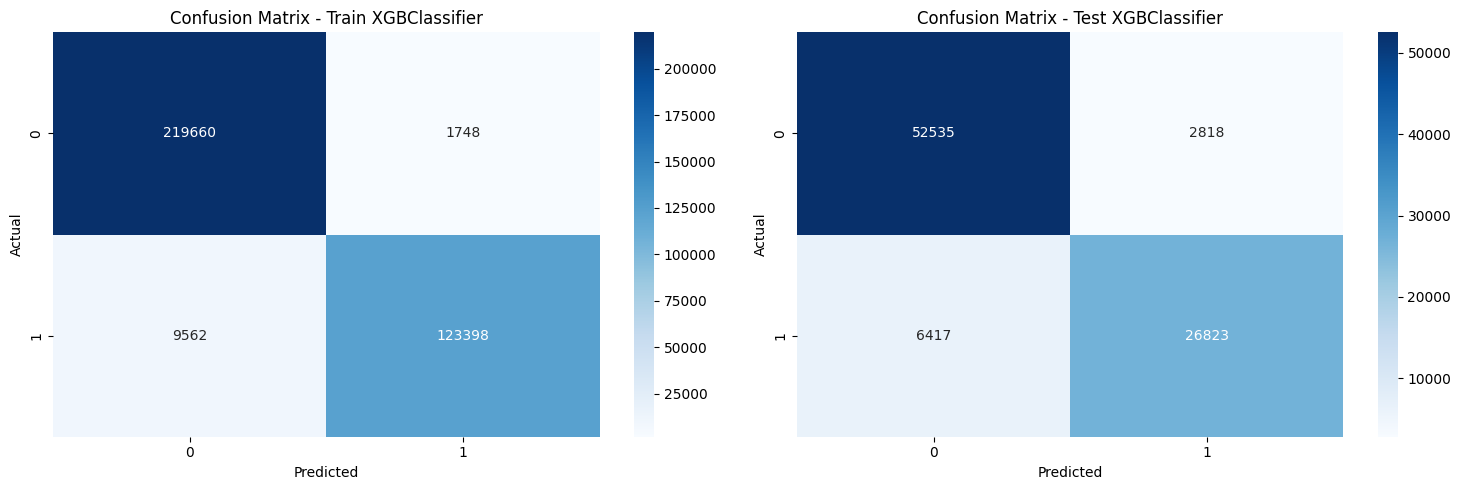

In [137]:
confusion_matrix_graf(    
    # ваша обученная модель
    model=xgb,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier'
)

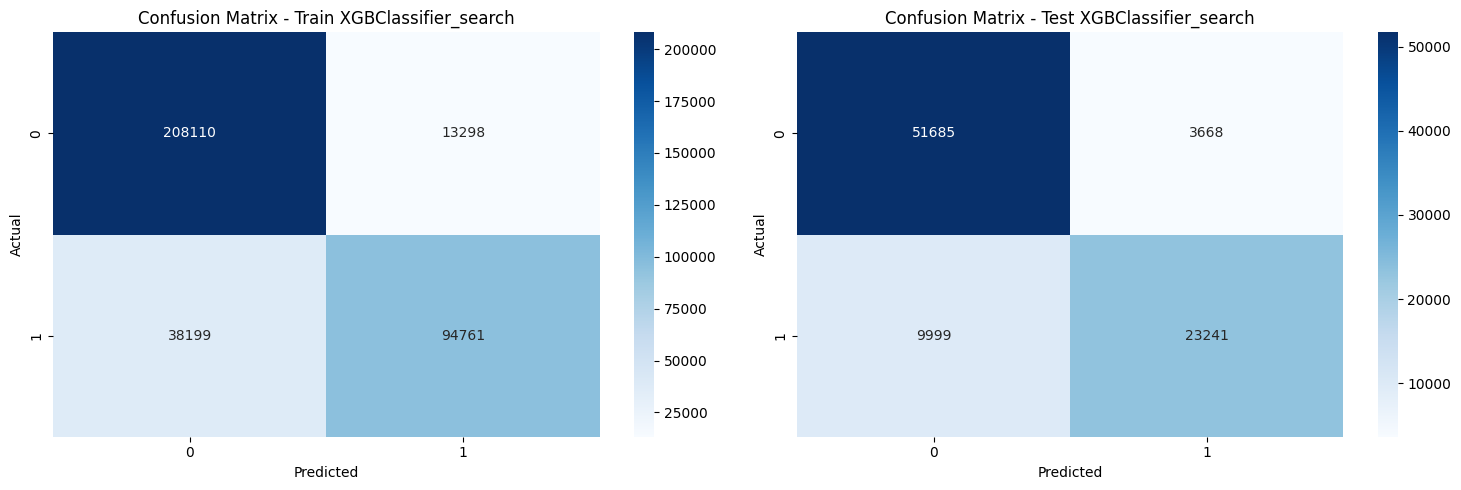

In [135]:
confusion_matrix_graf(    
    # ваша обученная модель
    model=random_search,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier_search'
)

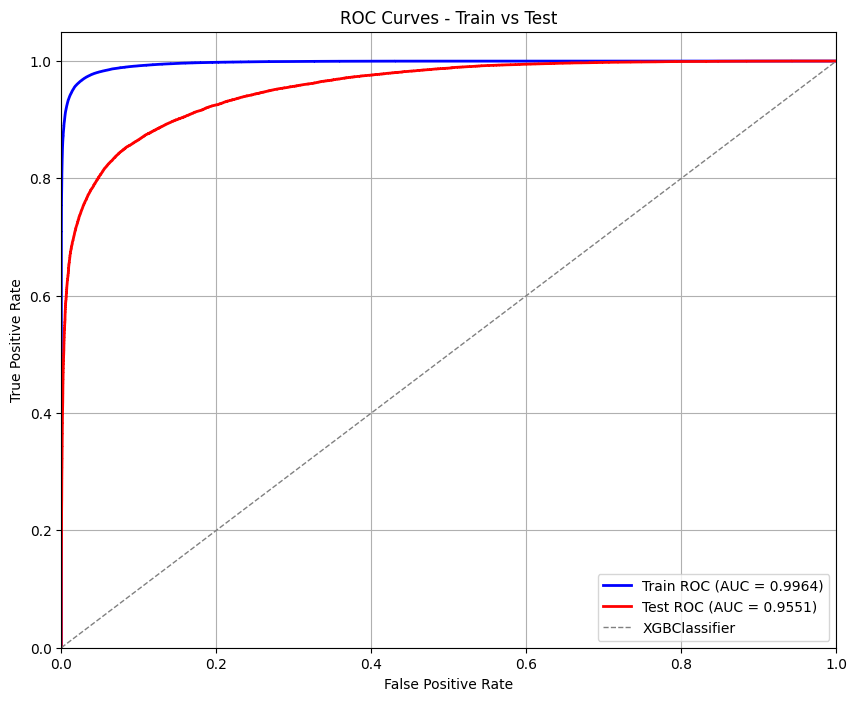

In [138]:
roc_curves_graf(
    model=xgb,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier'
)

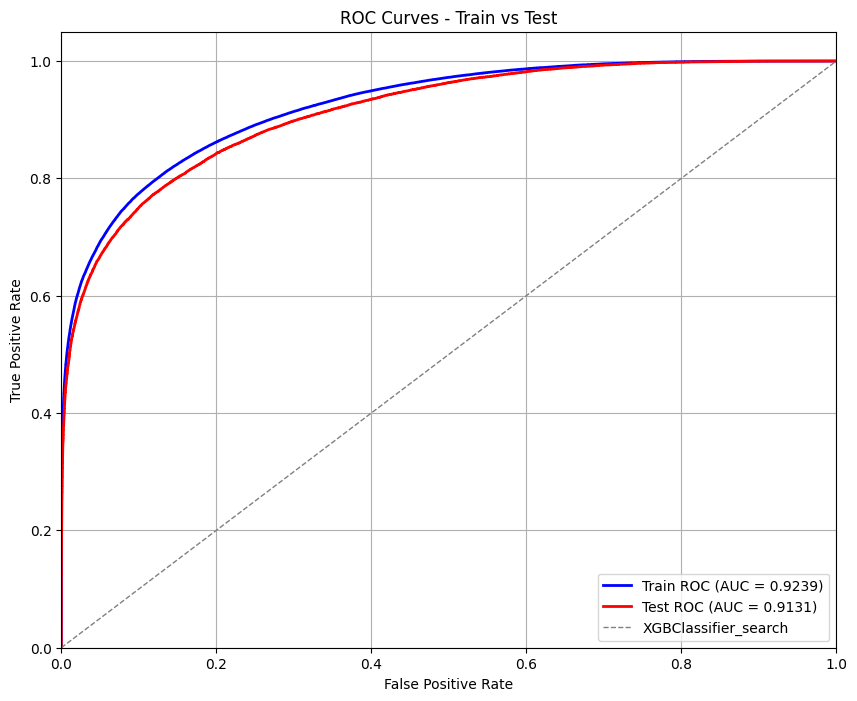

In [139]:
roc_curves_graf(
    model=random_search,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier_search'
)

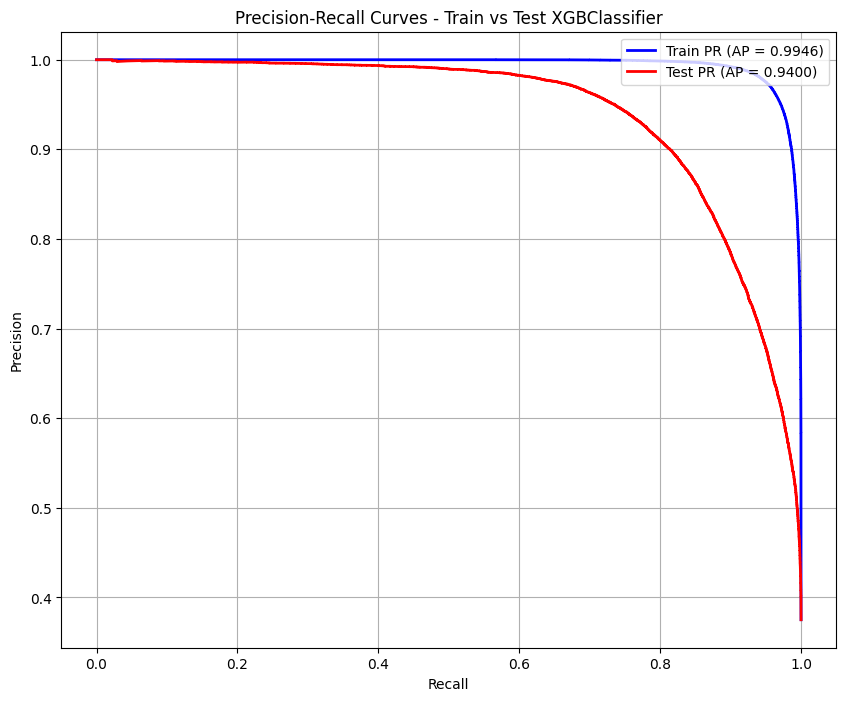

In [140]:
precision_recall_curves_graf(
    model=xgb,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier'
)

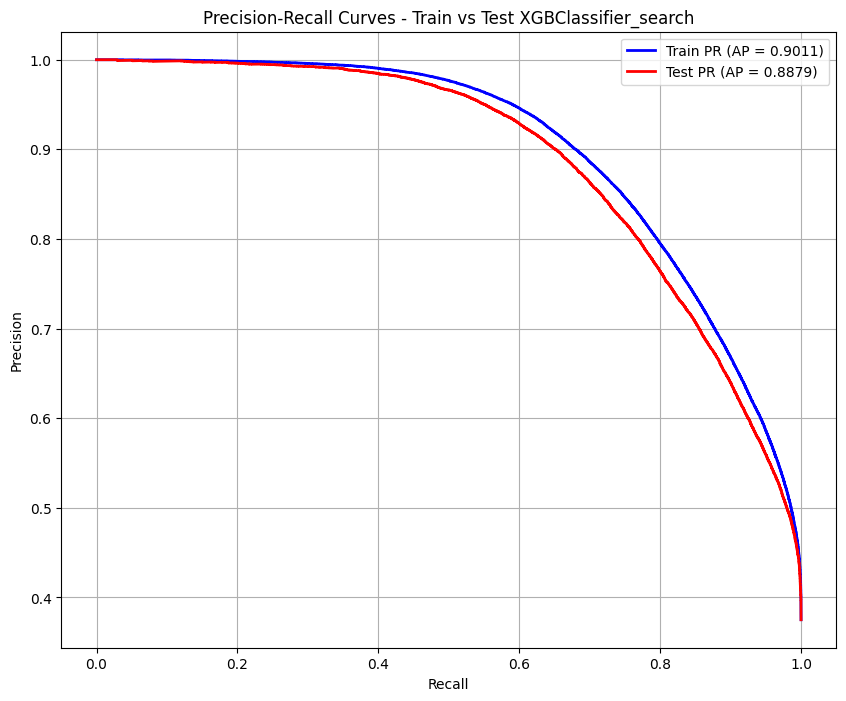

In [141]:
precision_recall_curves_graf(
    model=random_search,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='XGBClassifier_search'
)

In [142]:
lgbm = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=21
    )

In [143]:
lgbm.fit(X_train_scaled, y_train)

[LightGBM] [Info] Number of positive: 132960, number of negative: 221408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036295 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17808
[LightGBM] [Info] Number of data points in the train set: 354368, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375203 -> initscore=-0.509959
[LightGBM] [Info] Start training from score -0.509959


LGBMClassifier(colsample_bytree=0.8, max_depth=8, n_estimators=1000,
               random_state=21, subsample=0.8)

In [144]:
results_df = evaluate_model(
    model=lgbm,  # ваша обученная модель
    X_train=X_train_scaled,
    X_test=X_test_scaled, 
    y_train=y_train,
    y_test=y_test,
    model_name='LGBMClassifier',
    results_df=results_df
)

In [190]:
results_df.sort_values(by='Test_Precision', ascending=False)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_AP
0,Random Forest,0.897859,0.930552,0.786462,0.852461,0.958292,0.943403
4,LGBMClassifier,0.871277,0.893896,0.745397,0.812920,0.936956,0.916654
3,XGBClassifier_search,0.845733,0.863689,0.699188,0.772781,0.913127,0.887939
2,XGBClassifier,0.834129,0.851085,0.676233,0.753650,0.899627,0.872602
1,Logistic Regression,0.772781,0.761949,0.573616,0.654504,0.793777,0.757827


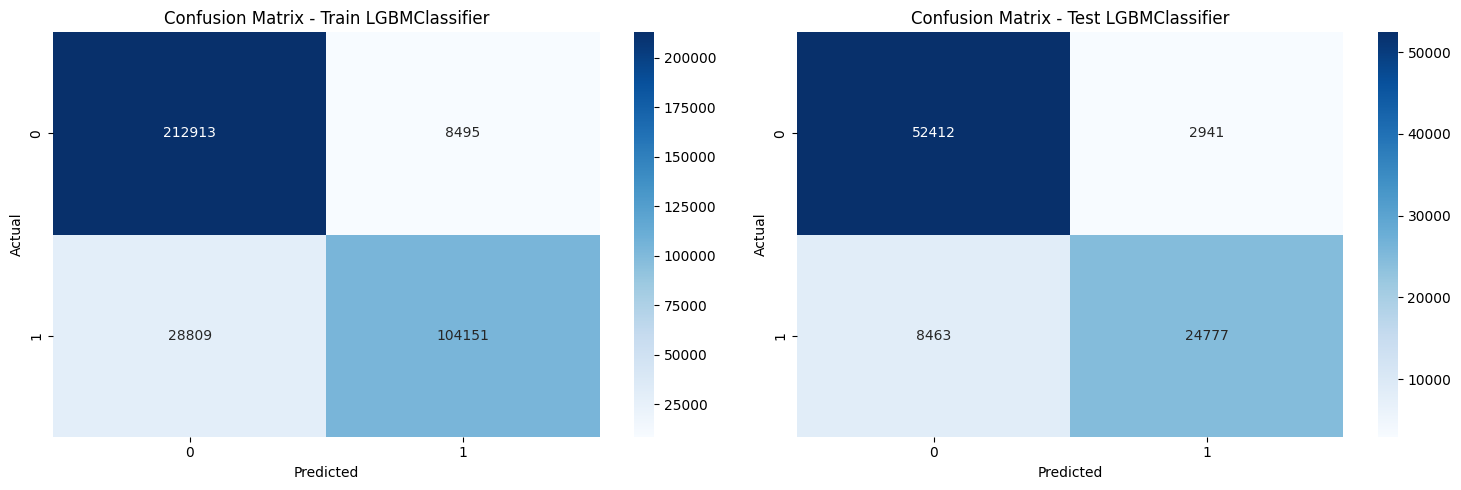

In [147]:
confusion_matrix_graf(    
    # ваша обученная модель
    model=lgbm,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='LGBMClassifier'
)

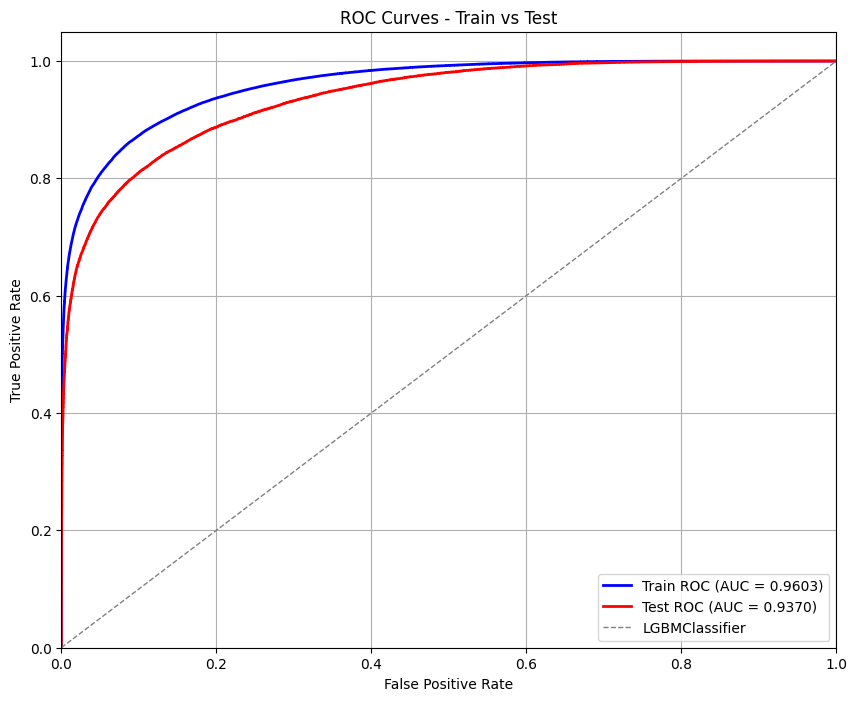

In [146]:
roc_curves_graf(
    model=lgbm,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='LGBMClassifier'
)

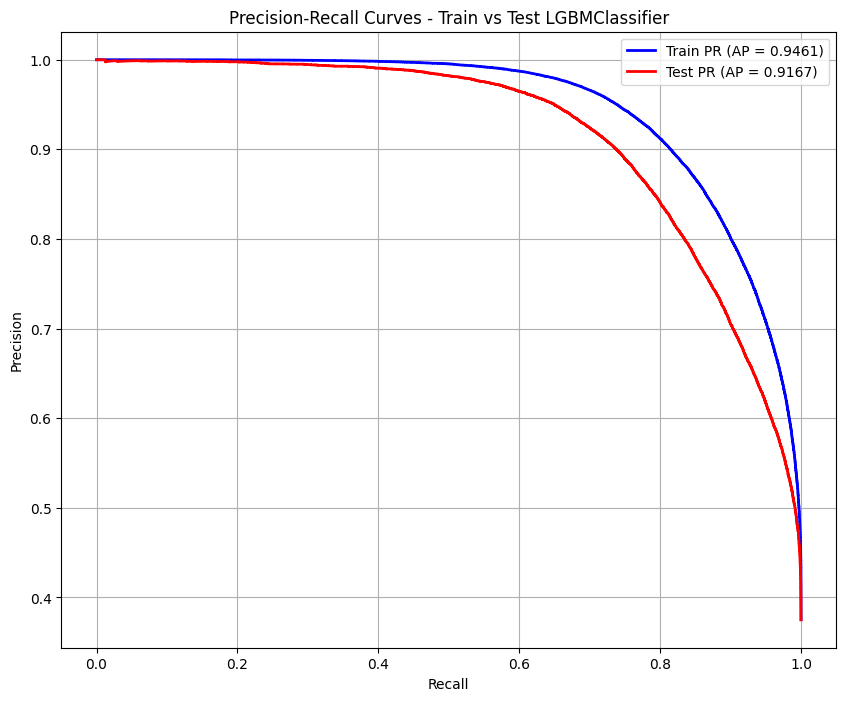

In [148]:
precision_recall_curves_graf(
    model=lgbm,
    X_train=X_train_scaled, 
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name='LGBMClassifier'
)

In [204]:
for model in [rfc, xgb, lgbm]:
    feature_importance = pd.DataFrame({
        'feature': X_train_scaled.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(model)
    print()
    print("Топ-10 признаков для класса 1")
    print(feature_importance.head(10))
    print('_______________________________________________________')

RandomForestClassifier(n_jobs=-1, random_state=21)

Топ-10 признаков для класса 1
                                    feature  importance
23                              risk_factor    0.129161
31                          max_risk_factor    0.068033
30                          avg_risk_factor    0.062274
29  risk_factor_above_threshold_daily_count    0.052031
45               time_since_last_liquidated    0.023384
41                 time_since_first_deposit    0.023178
4                                wallet_age    0.016431
26              total_available_borrows_eth    0.015497
27          total_available_borrows_avg_eth    0.015389
46               liquidation_amount_sum_eth    0.014584
_______________________________________________________
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_m